<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/Classification/Kernel_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Importing datasets

In [4]:
df = pd.read_csv("/content/Social_Network_Ads.csv")
X = df.iloc[:, 2:-1].values
y = df.iloc[:, -1].values

##Splitting the dataset into the traning and test set

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

##Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

##Training Kernel SVM model on the Training set

In [7]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(X_train, y_train)

SVC(random_state=0)

##Predicting a new result

In [10]:
print(classifier.predict(sc.transform([[30, 87000]])))

[0]


##Predicting Test set results

In [12]:
y_pred = classifier.predict(X_test)
y_pred_vector = y_pred.reshape(len(y_pred), -1)
y_test_vector = y_test.reshape(len(y_test), -1)
print(np.concatenate((y_pred_vector, y_test_vector), 1))

array([[0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0,

##Making confusion matrix

In [13]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[64  4]
 [ 3 29]]


###HeatMap

Text(0.5, 1.0, 'Confusion matrix')

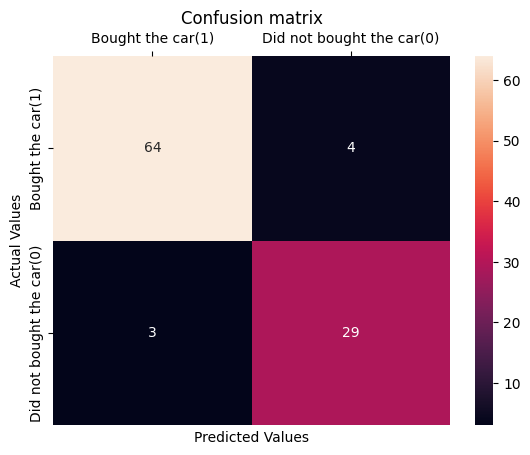

In [27]:
import seaborn as sns

sns.heatmap(cm, annot=True, xticklabels=["Bought the car(1)", "Did not bought the car(0)"], yticklabels=["Bought the car(1)", "Did not bought the car(0)"])
plt.tick_params(axis='x', labeltop=True, labelbottom=False, top=True, bottom=False)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")


plt.title("Confusion matrix")

##Accuracy Score

In [30]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred, y_test))

0.93
